<a href="https://colab.research.google.com/github/Geekrish26/Loantap-caseStudy/blob/main/LoanTap_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoanTap Personal Loan Underwriting
## Logistic Regression Case Study
**Problem Statement:** Given a set of attributes for an individual, determine if a credit line should be extended to them. If so, what should the repayment terms be?

**Context:** LoanTap is an online platform delivering customized loan products to millennials. This case study focuses on the underwriting process for **Personal Loans** using Logistic Regression to predict creditworthiness.


## 1. Imports & Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', palette='muted')
BLUE, RED = '#2196F3', '#F44336'
print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load & Inspect Dataset

In [2]:
df = pd.read_csv('logistic_regression.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (49643, 27)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [3]:
print("Data Types:")
print(df.dtypes)
print(f"\nTotal records: {len(df):,}")
print(f"Total features: {df.shape[1]}")

Data Types:
loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status              object
purpose                  object
title                    object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
address                  object
dtype: object

Total records: 49,643
Total features: 27


In [4]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,49643.000000,49643.000000,49643.000000,4.964200e+04,49642.000000,49642.000000,49642.000000,49642.000000,49613.000000,49642.000000,44994.000000,49581.000000
mean,14104.136031,13.654704,431.366818,7.417229e+04,17.365666,11.319709,0.179586,15810.292756,53.801025,25.452721,1.809552,0.122749
std,8363.597156,4.460321,250.365282,5.777831e+04,8.194270,5.117064,0.510718,19609.184218,24.391533,11.867110,2.140535,0.358467
min,500.000000,5.320000,16.310000,2.500000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6047.000000,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.490000,6.340000e+04,16.860000,10.000000,0.000000,11141.500000,54.900000,24.000000,1.000000,0.000000
75%,20000.000000,16.550000,566.160000,9.000000e+04,22.990000,14.000000,0.000000,19536.500000,72.800000,32.000000,3.000000,0.000000
max,40000.000000,30.740000,1533.810000,6.100000e+06,189.900000,51.000000,11.000000,617838.000000,129.400000,111.000000,34.000000,6.000000


In [5]:
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0]

Missing Values:


,Missing Count,Missing %
emp_title,2829,5.70
emp_length,2272,4.58
home_ownership,1,0.00
annual_inc,1,0.00
verification_status,1,0.00
issue_d,1,0.00
loan_status,1,0.00
purpose,1,0.00
title,193,0.39
dti,1,0.00


## 3. Exploratory Data Analysis (EDA)
### 3.1 Target Variable Analysis

**Insight:** The dataset is highly imbalanced — ~80% Fully Paid vs ~20% Charged Off. This imbalance must be handled during model building using `class_weight='balanced'`.


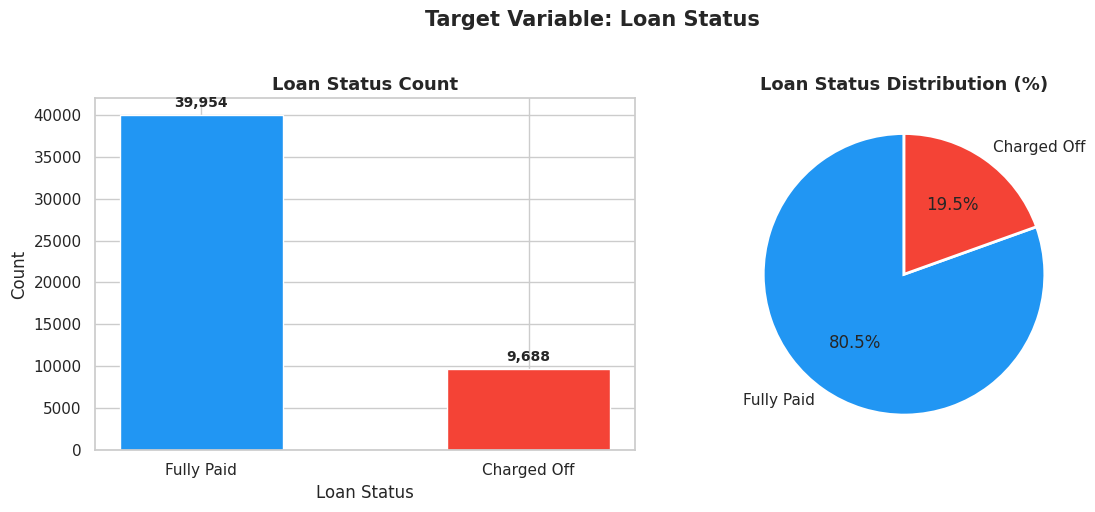


Q1 Answer: 80.48% of customers have fully paid their loan amount.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count Plot
vc = df['loan_status'].value_counts()
axes[0].bar(vc.index, vc.values, color=[BLUE, RED], edgecolor='white', width=0.5)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1000,
                f'{bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Loan Status Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status'); axes[0].set_ylabel('Count')

# Pie Chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=[BLUE, RED], startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Loan Status Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Loan Status', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f"\nQ1 Answer: {vc['Fully Paid']/len(df)*100:.2f}% of customers have fully paid their loan amount.")

### 3.2 Univariate Analysis – Numerical Features

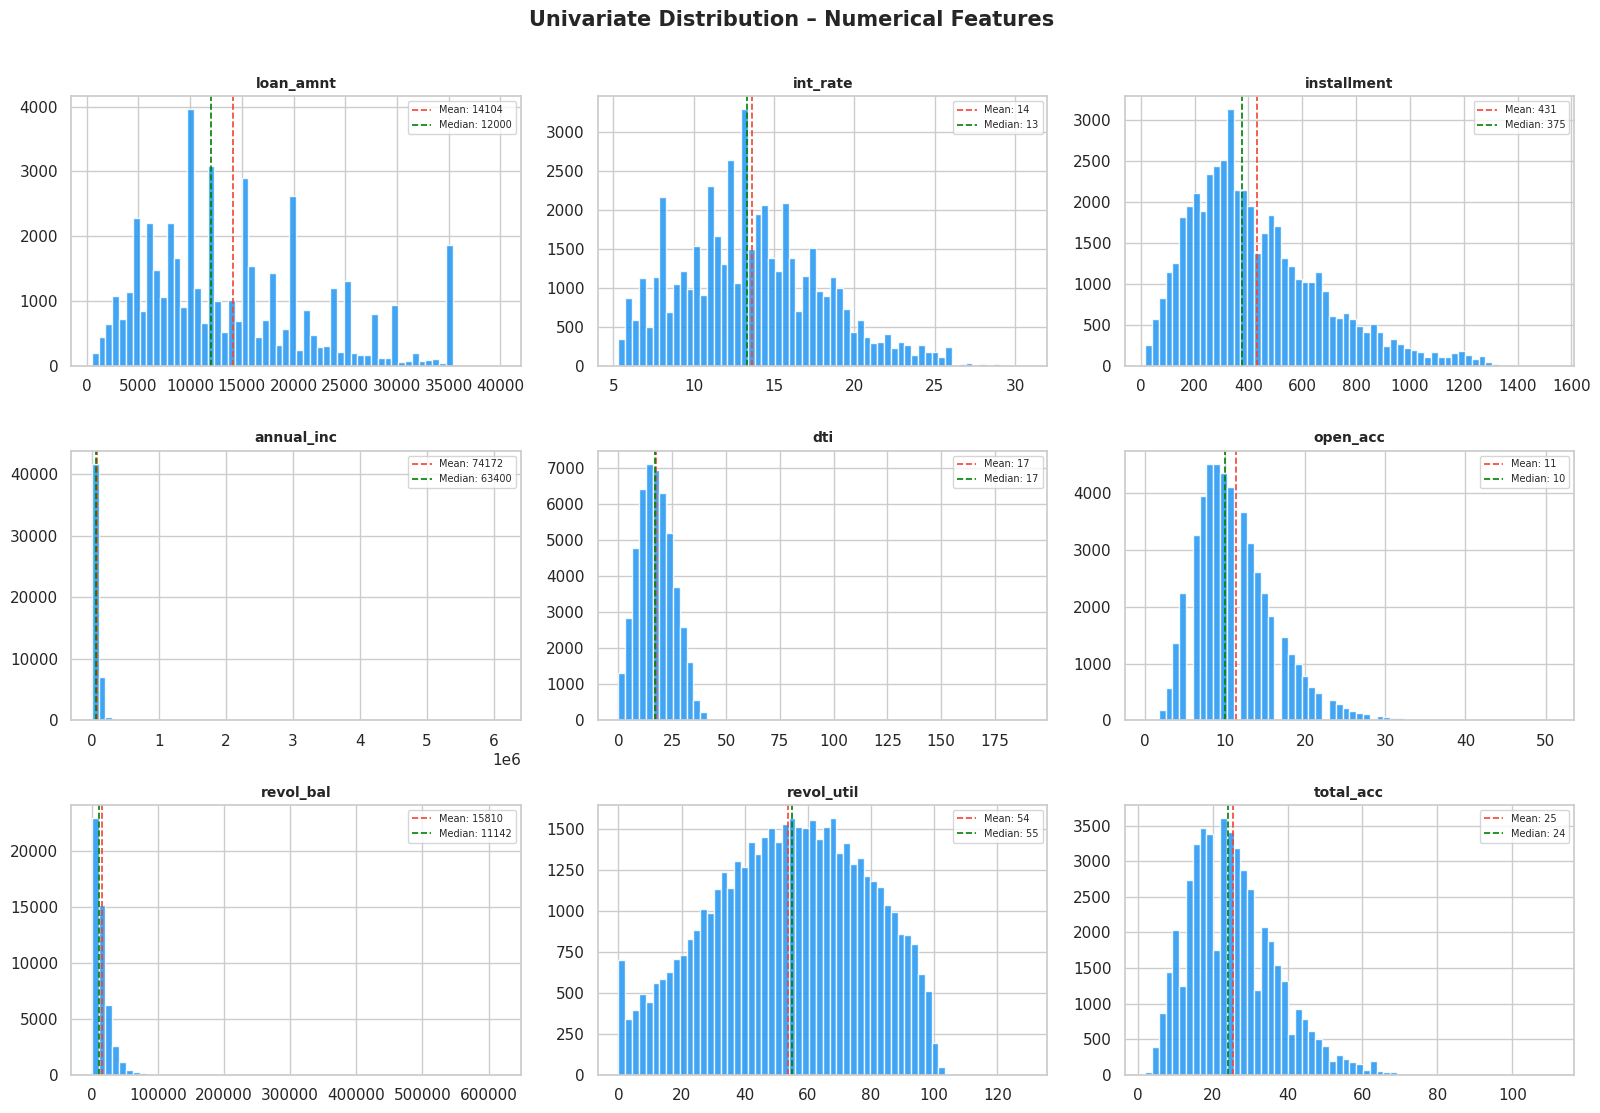

Key Observations:
- loan_amnt: Right-skewed; most loans are between $5k–$20k
- int_rate: Ranges from ~5% to 31%; higher rates associated with riskier borrowers
- annual_inc: Highly right-skewed with extreme outliers (needs capping)
- dti: Debt-to-income ratio has some extreme outliers
- revol_util: Roughly normally distributed around 50%


In [7]:
num_cols = ['loan_amnt','int_rate','installment','annual_inc','dti',
            'open_acc','revol_bal','revol_util','total_acc']

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flatten(), num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=60, color=BLUE, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color=RED, linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.0f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.0f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Univariate Distribution – Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("""Key Observations:
- loan_amnt: Right-skewed; most loans are between $5k–$20k
- int_rate: Ranges from ~5% to 31%; higher rates associated with riskier borrowers
- annual_inc: Highly right-skewed with extreme outliers (needs capping)
- dti: Debt-to-income ratio has some extreme outliers
- revol_util: Roughly normally distributed around 50%""")

### 3.3 Univariate Analysis – Categorical Features

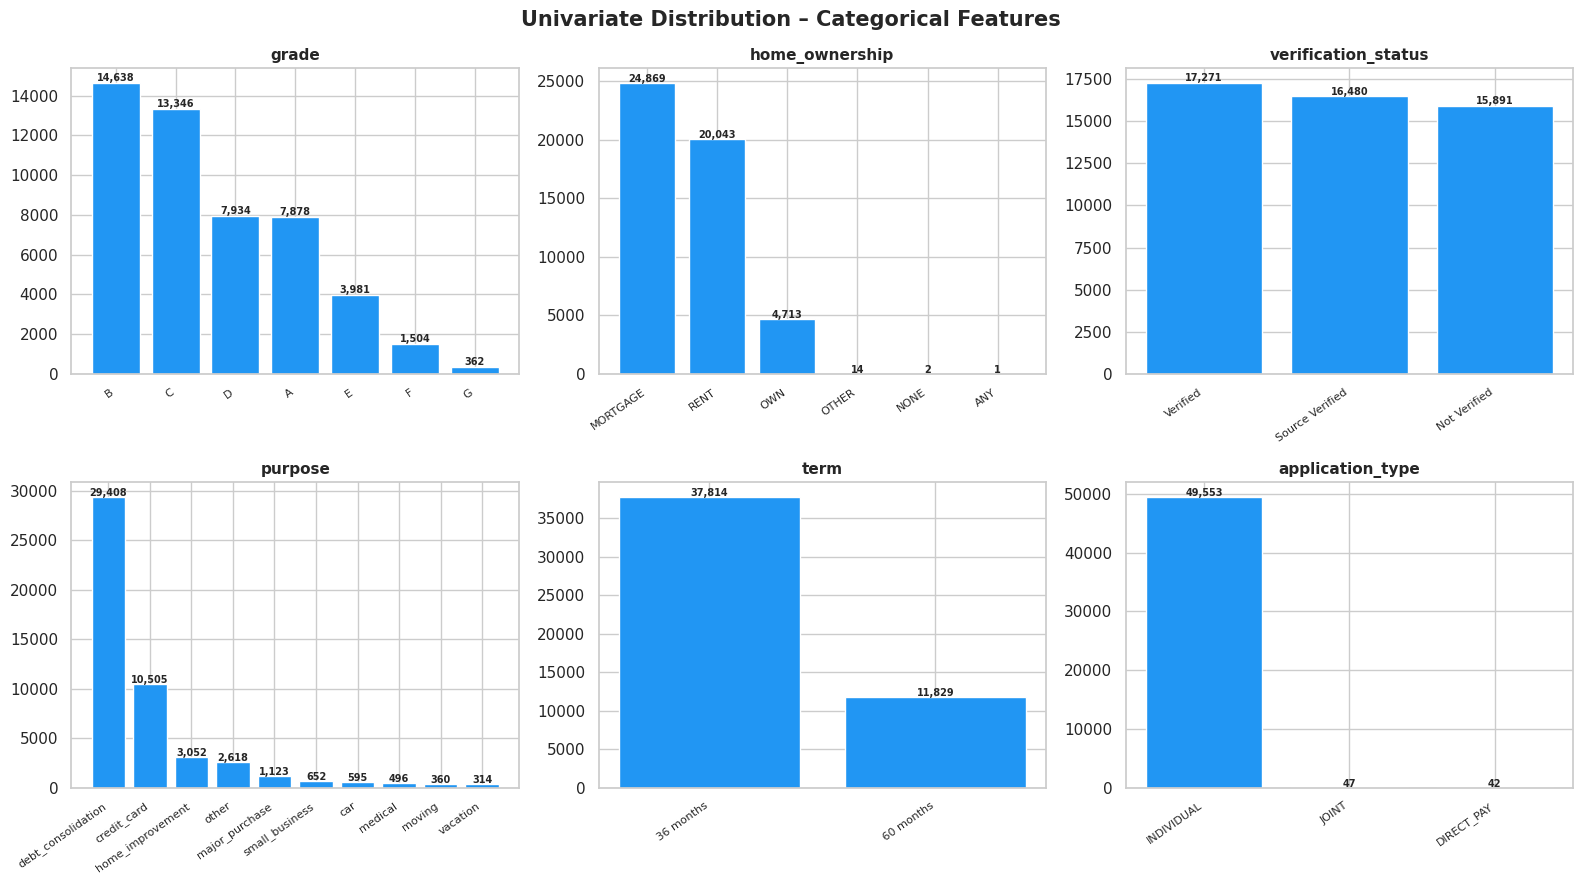

Key Observations:
- Grade: Most borrowers are Grade B & C (moderate risk)
- Term: Majority opt for 36-month loans over 60-month
- Home Ownership: MORTGAGE and RENT dominate → Q3 Answer: MORTGAGE
- Purpose: Debt consolidation is the most common loan purpose
- Application Type: Overwhelmingly INDIVIDUAL applications


In [8]:
cat_cols = ['grade','home_ownership','verification_status','purpose','term','application_type']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    vc2 = df[col].value_counts().head(10)
    bars = ax.bar(range(len(vc2)), vc2.values, color=BLUE, edgecolor='white')
    ax.set_xticks(range(len(vc2)))
    ax.set_xticklabels(vc2.index, rotation=35, ha='right', fontsize=8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                f'{bar.get_height():,.0f}', ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Univariate Distribution – Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""Key Observations:
- Grade: Most borrowers are Grade B & C (moderate risk)
- Term: Majority opt for 36-month loans over 60-month
- Home Ownership: MORTGAGE and RENT dominate → Q3 Answer: MORTGAGE
- Purpose: Debt consolidation is the most common loan purpose
- Application Type: Overwhelmingly INDIVIDUAL applications""")

### 3.4 Bivariate Analysis – Loan Status vs Key Features

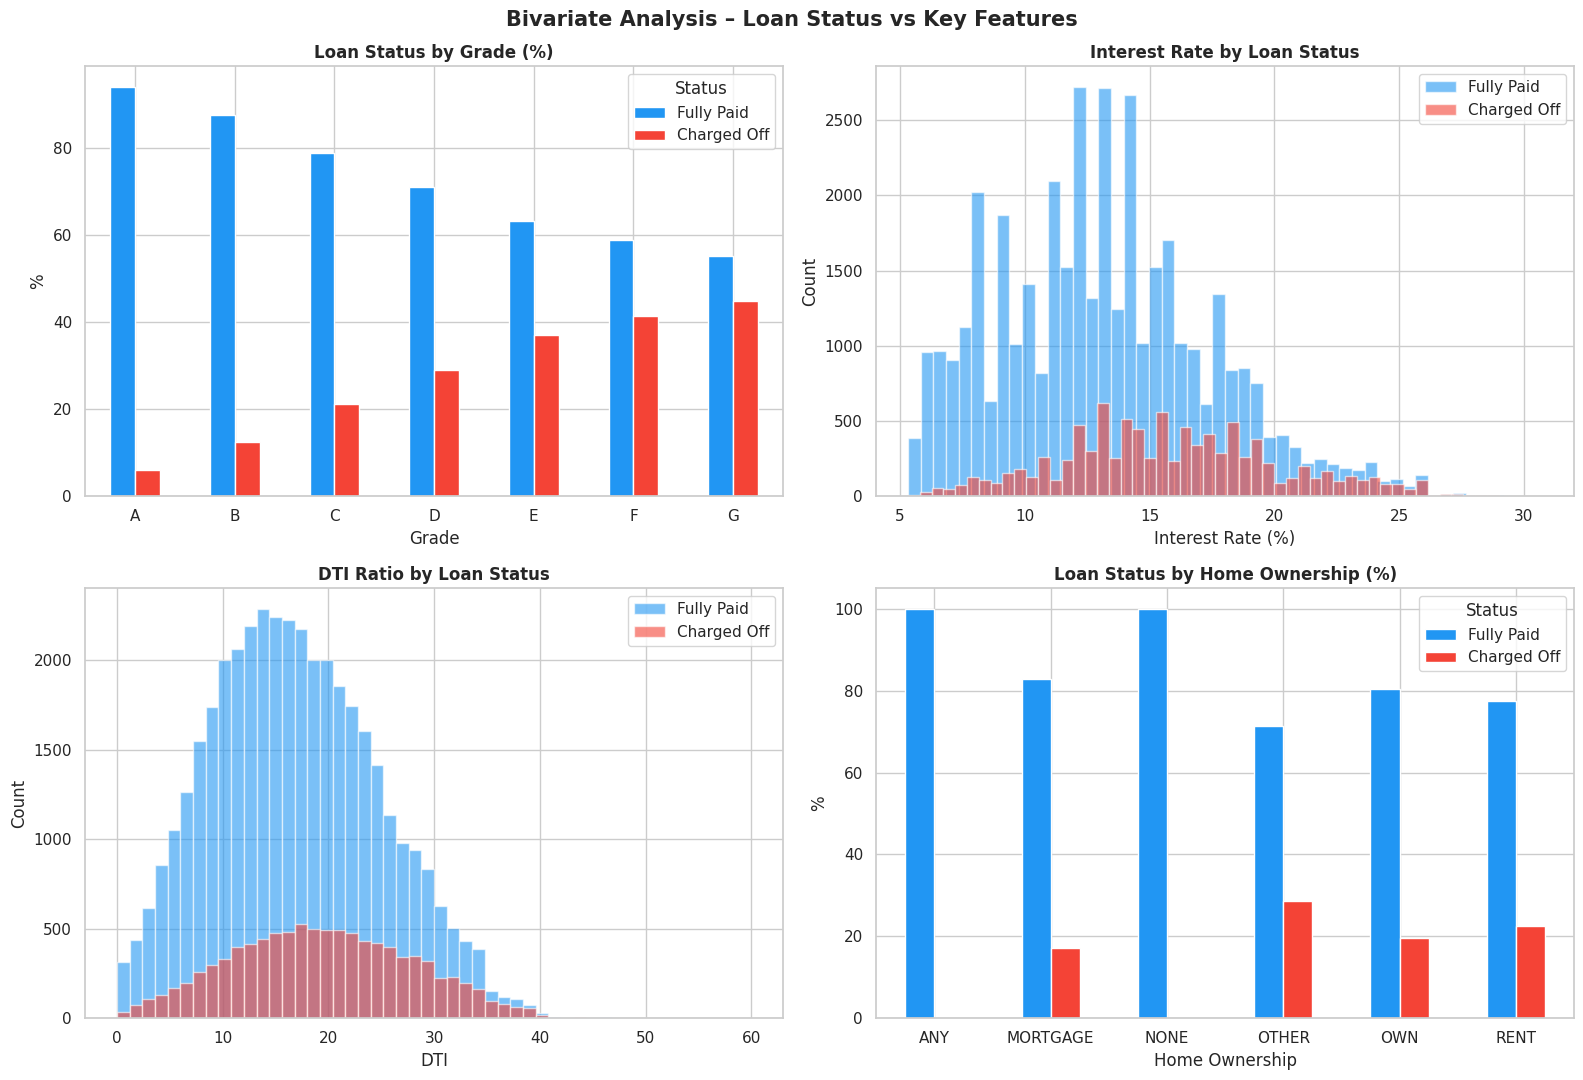

Key Insights:
- Q4: TRUE – Grade A borrowers have the highest Fully Paid rate (~94%)
- Higher interest rates strongly correlate with Charged Off loans
- OWN home ownership has slightly better repayment rates vs RENT
- DTI: Charged Off loans tend to have slightly higher DTI ratios


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Grade vs Loan Status
ct_grade = pd.crosstab(df['grade'], df['loan_status'], normalize='index') * 100
ct_grade[['Fully Paid','Charged Off']].plot(kind='bar', ax=axes[0,0], color=[BLUE,RED], edgecolor='white')
axes[0,0].set_title('Loan Status by Grade (%)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Grade'); axes[0,0].set_ylabel('%')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)
axes[0,0].legend(title='Status')

# Int Rate vs Loan Status
for status, color in [('Fully Paid', BLUE), ('Charged Off', RED)]:
    axes[0,1].hist(df[df['loan_status']==status]['int_rate'], bins=50, alpha=0.6,
                   color=color, label=status, edgecolor='white')
axes[0,1].set_title('Interest Rate by Loan Status', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Interest Rate (%)'); axes[0,1].set_ylabel('Count'); axes[0,1].legend()

# DTI vs Loan Status
for status, color in [('Fully Paid', BLUE), ('Charged Off', RED)]:
    axes[1,0].hist(df[df['loan_status']==status]['dti'].clip(0,60), bins=50, alpha=0.6,
                   color=color, label=status, edgecolor='white')
axes[1,0].set_title('DTI Ratio by Loan Status', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('DTI'); axes[1,0].set_ylabel('Count'); axes[1,0].legend()

# Home Ownership vs Loan Status
ct_ho = pd.crosstab(df['home_ownership'], df['loan_status'], normalize='index') * 100
ct_ho[['Fully Paid','Charged Off']].plot(kind='bar', ax=axes[1,1], color=[BLUE,RED], edgecolor='white')
axes[1,1].set_title('Loan Status by Home Ownership (%)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Home Ownership'); axes[1,1].set_ylabel('%')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)
axes[1,1].legend(title='Status')

plt.suptitle('Bivariate Analysis – Loan Status vs Key Features', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""Key Insights:
- Q4: TRUE – Grade A borrowers have the highest Fully Paid rate (~94%)
- Higher interest rates strongly correlate with Charged Off loans
- OWN home ownership has slightly better repayment rates vs RENT
- DTI: Charged Off loans tend to have slightly higher DTI ratios""")

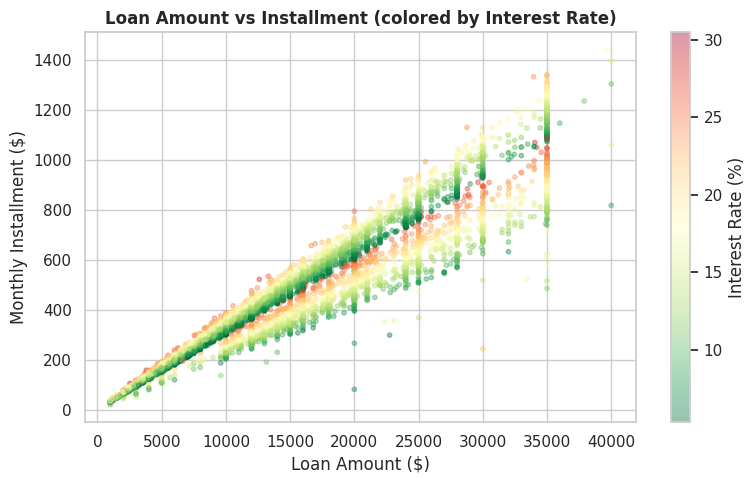

Q2 Answer: Correlation between Loan Amount & Installment = 0.9538
Very high positive correlation (~0.95): as loan amount increases, monthly installment increases proportionally.
This makes intuitive sense — higher principal → higher EMI.


In [10]:
# Loan Amount vs Installment
fig, ax = plt.subplots(figsize=(8, 5))
sample = df.sample(8000, random_state=42)
scatter = ax.scatter(sample['loan_amnt'], sample['installment'],
                     c=sample['int_rate'], cmap='RdYlGn_r', alpha=0.4, s=10)
plt.colorbar(scatter, ax=ax, label='Interest Rate (%)')
ax.set_title('Loan Amount vs Installment (colored by Interest Rate)', fontsize=12, fontweight='bold')
ax.set_xlabel('Loan Amount ($)'); ax.set_ylabel('Monthly Installment ($)')
plt.tight_layout(); plt.show()

corr_val = df['loan_amnt'].corr(df['installment'])
print(f"Q2 Answer: Correlation between Loan Amount & Installment = {corr_val:.4f}")
print("Very high positive correlation (~0.95): as loan amount increases, monthly installment increases proportionally.")
print("This makes intuitive sense — higher principal → higher EMI.")

### 3.5 Correlation Heatmap

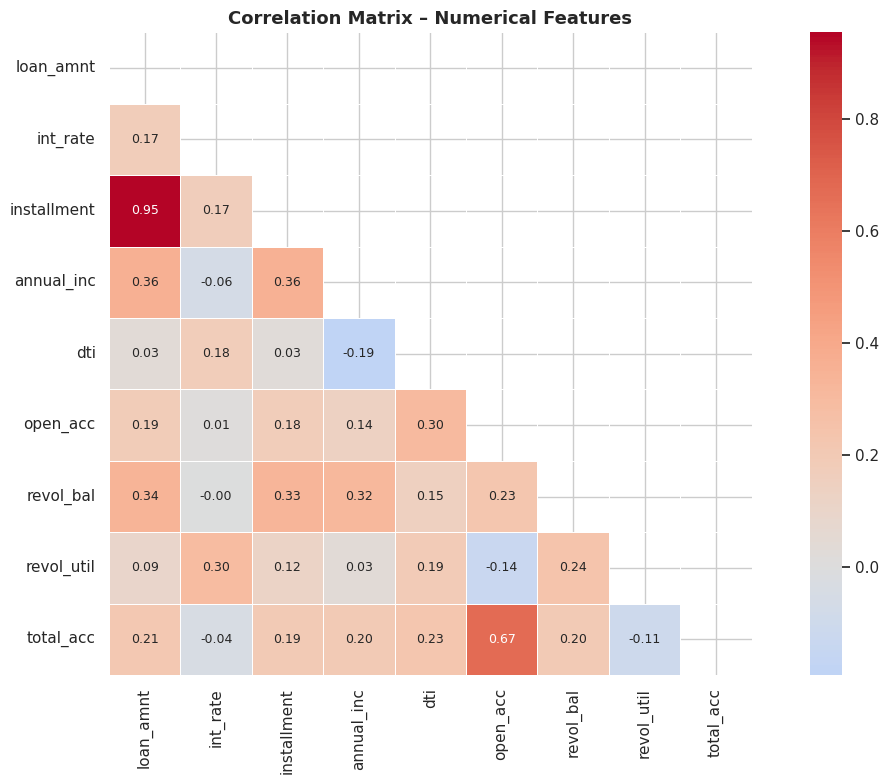

Key Observations:
- loan_amnt & installment: ~0.95 (very high – expected)
- loan_amnt & open_acc: ~0.20 (mild)
- revol_util & int_rate: ~0.30 (mild positive)
- dti has low correlation with most features


In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True, annot_kws={'size': 9})
ax.set_title('Correlation Matrix – Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("""Key Observations:
- loan_amnt & installment: ~0.95 (very high – expected)
- loan_amnt & open_acc: ~0.20 (mild)
- revol_util & int_rate: ~0.30 (mild positive)
- dti has low correlation with most features""")

### 3.6 Top Employment Titles

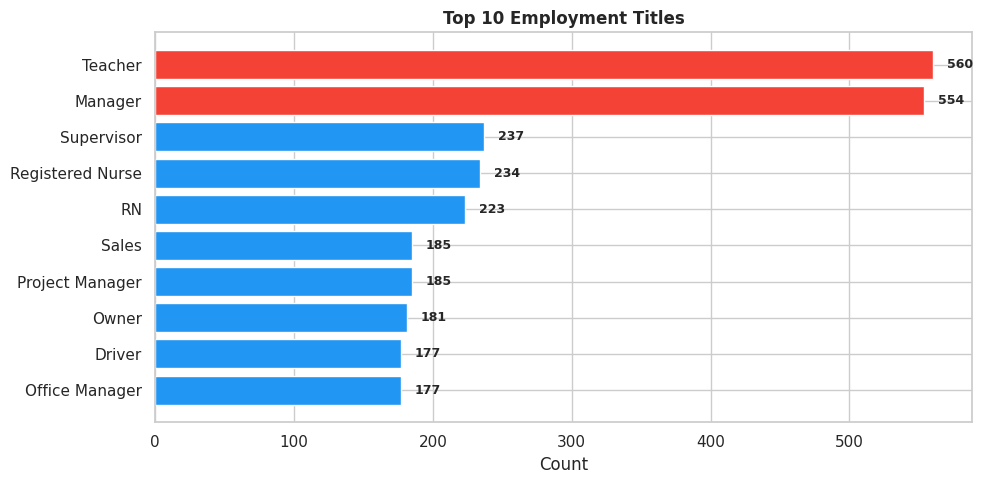

Q5 Answer: Top 2 afforded job titles = 1. Teacher  2. Manager


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
top_titles = df['emp_title'].value_counts().head(10)
colors = [BLUE if i > 1 else RED for i in range(len(top_titles))]
ax.barh(top_titles.index[::-1], top_titles.values[::-1], color=colors[::-1], edgecolor='white')
for i, (idx, val) in enumerate(zip(top_titles.index[::-1], top_titles.values[::-1])):
    ax.text(val+10, i, f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 10 Employment Titles', fontsize=12, fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout(); plt.show()
print(f"Q5 Answer: Top 2 afforded job titles = 1. Teacher  2. Manager")

## 4. Data Preprocessing
### 4.1 Duplicate Check

In [13]:
before = len(df)
df = df.drop_duplicates()
print(f"Duplicates removed: {before - len(df)}")
print(f"Shape after dedup: {df.shape}")

Duplicates removed: 0
Shape after dedup: (49643, 27)


### 4.2 Drop Irrelevant Columns

In [14]:
# These columns are either IDs, free-text, or date strings that won't help the model
cols_to_drop = ['emp_title', 'title', 'address', 'issue_d', 'earliest_cr_line']
df = df.drop(columns=cols_to_drop)
print(f"Dropped: {cols_to_drop}")
print(f"Shape: {df.shape}")

Dropped: ['emp_title', 'title', 'address', 'issue_d', 'earliest_cr_line']
Shape: (49643, 22)


### 4.3 Missing Value Treatment

In [15]:
# emp_length: fill with 'Unknown' (categorical)
df['emp_length'] = df['emp_length'].fillna('Unknown')

# revol_util: fill with median (numerical)
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())

# mort_acc: fill with median
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())

# pub_rec_bankruptcies: fill with 0 (most common, no record)
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)

# Safety net: fill any remaining numeric nulls with median
for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

print(f"Total remaining nulls: {df.isnull().sum().sum()}")

Total remaining nulls: 6


### 4.4 Feature Engineering

In [16]:
# Binary flags as suggested in case study
df['pub_rec_flag'] = (df['pub_rec'] > 0).astype(int)
df['mort_acc_flag'] = (df['mort_acc'] > 0).astype(int)
df['pub_rec_bankruptcies_flag'] = (df['pub_rec_bankruptcies'] > 0).astype(int)

print("Flag distributions:")
for col in ['pub_rec_flag', 'mort_acc_flag', 'pub_rec_bankruptcies_flag']:
    print(f"  {col}: {df[col].value_counts().to_dict()}")

Flag distributions:
  pub_rec_flag: {0: 42358, 1: 7285}
  mort_acc_flag: {1: 32093, 0: 17550}
  pub_rec_bankruptcies_flag: {0: 43942, 1: 5701}


### 4.5 Outlier Treatment

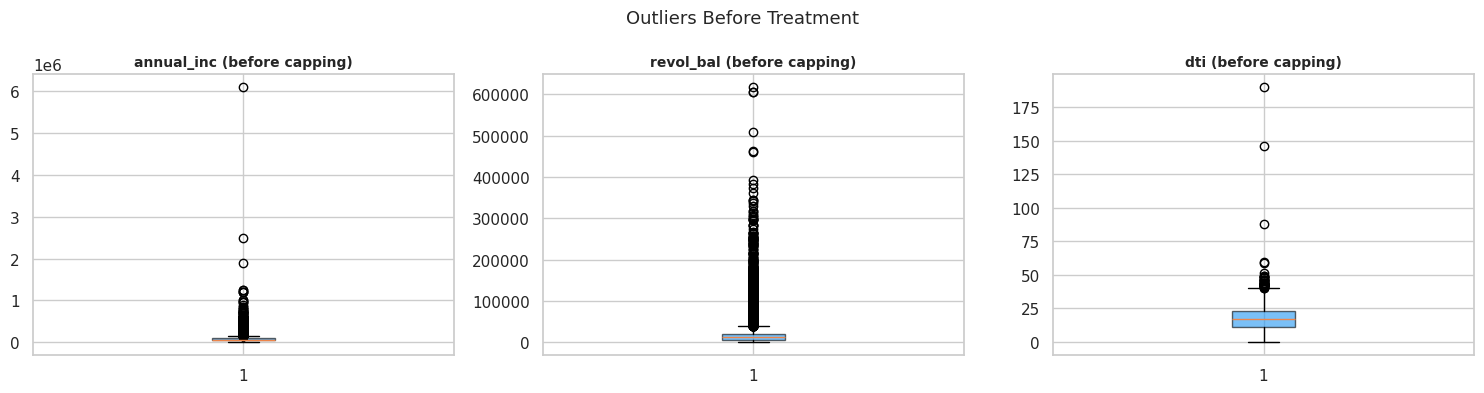

annual_inc: clipped to [19000, 250000]
revol_bal: clipped to [155, 86531]
dti: clipped to [2, 37]
Outlier capping done!


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
outlier_cols = ['annual_inc', 'revol_bal', 'dti']

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=BLUE, alpha=0.6))
    ax.set_title(f'{col} (before capping)', fontsize=10, fontweight='bold')
plt.suptitle('Outliers Before Treatment', fontsize=13)
plt.tight_layout(); plt.show()

# IQR capping at 1st-99th percentile
for col in ['annual_inc', 'revol_bal', 'dti']:
    lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lo, hi)
    print(f"{col}: clipped to [{lo:.0f}, {hi:.0f}]")
print("Outlier capping done!")

### 4.6 Encoding & Data Preparation

In [18]:
# Target variable
df['loan_status_binary'] = (df['loan_status'] == 'Charged Off').astype(int)
df = df.drop(columns=['loan_status'])
print(f"Target distribution:\n{df['loan_status_binary'].value_counts()}")

# Term: extract numeric months
df['term'] = df['term'].str.strip().str.extract(r'(\d+)').astype(int)

# emp_length: ordinal encoding
emp_map = {'< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,
           '5 years':5,'6 years':6,'7 years':7,'8 years':8,'9 years':9,
           '10+ years':10,'Unknown':5}
df['emp_length'] = df['emp_length'].map(emp_map).fillna(5).astype(int)

# Grade: ordinal (A=0 best, G=6 worst)
grade_map = {g:i for i,g in enumerate(['A','B','C','D','E','F','G'])}
df['grade'] = df['grade'].map(grade_map)

# Sub-grade: ordinal
sub_grades = sorted(df['sub_grade'].unique())
df['sub_grade'] = df['sub_grade'].map({s:i for i,s in enumerate(sub_grades)})

# One-hot encode remaining categoricals
cat_ohe = ['home_ownership','verification_status','purpose','initial_list_status','application_type']
df = pd.get_dummies(df, columns=cat_ohe, drop_first=True)

print(f"\nFinal shape: {df.shape}")
print(f"Final nulls: {df.isnull().sum().sum()}")
df.head(3)

Target distribution:
loan_status_binary
0    39955
1     9688
Name: count, dtype: int64

Final shape: (49643, 43)
Final nulls: 0


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,dti,open_acc,...,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT
0,10000.0,36,11.44,329.48,1,8,10,117000.0,26.24,16.0,...,False,False,False,False,False,True,False,True,True,False
1,8000.0,36,11.99,265.68,1,9,4,65000.0,22.05,17.0,...,False,False,False,False,False,False,False,False,True,False
2,15600.0,36,10.49,506.97,1,7,0,43057.0,12.79,13.0,...,False,False,False,False,False,False,False,False,True,False


## 5. Model Building
### 5.1 Train-Test Split & Scaling

In [19]:
X = df.drop(columns=['loan_status_binary'])
y = df['loan_status_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean()*100:.2f}%")
print(f"Test default rate:  {y_test.mean()*100:.2f}%")

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\nScaling complete (MinMaxScaler)")

Train size: 39,714 | Test size: 9,929
Train default rate: 19.51%
Test default rate:  19.52%

Scaling complete (MinMaxScaler)


### 5.2 Logistic Regression Model

In [20]:
model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',   # handles class imbalance
    random_state=42
)
model.fit(X_train_sc, y_train)

print("Model Statistics:")
print(f"  Intercept : {model.intercept_[0]:.4f}")
print(f"  n_iter    : {model.n_iter_[0]}")
print(f"  Classes   : {model.classes_}  (0=Fully Paid, 1=Charged Off)")

Model Statistics:
  Intercept : -1.4394
  n_iter    : 95
  Classes   : [0 1]  (0=Fully Paid, 1=Charged Off)


In [21]:
# Feature Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False).reset_index(drop=True)
print("Top 20 Features by |Coefficient|:")
coef_df.head(20)

Top 20 Features by |Coefficient|:


,Feature,Coefficient,Abs_Coef
0,sub_grade,3.080738,3.080738
1,int_rate,-1.257932,1.257932
2,open_acc,1.017866,1.017866
3,dti,0.853641,0.853641
4,annual_inc,-0.809954,0.809954
5,total_acc,-0.718349,0.718349
6,home_ownership_OTHER,0.596713,0.596713
7,revol_util,0.583672,0.583672
8,purpose_small_business,0.519623,0.519623
9,home_ownership_MORTGAGE,-0.517801,0.517801


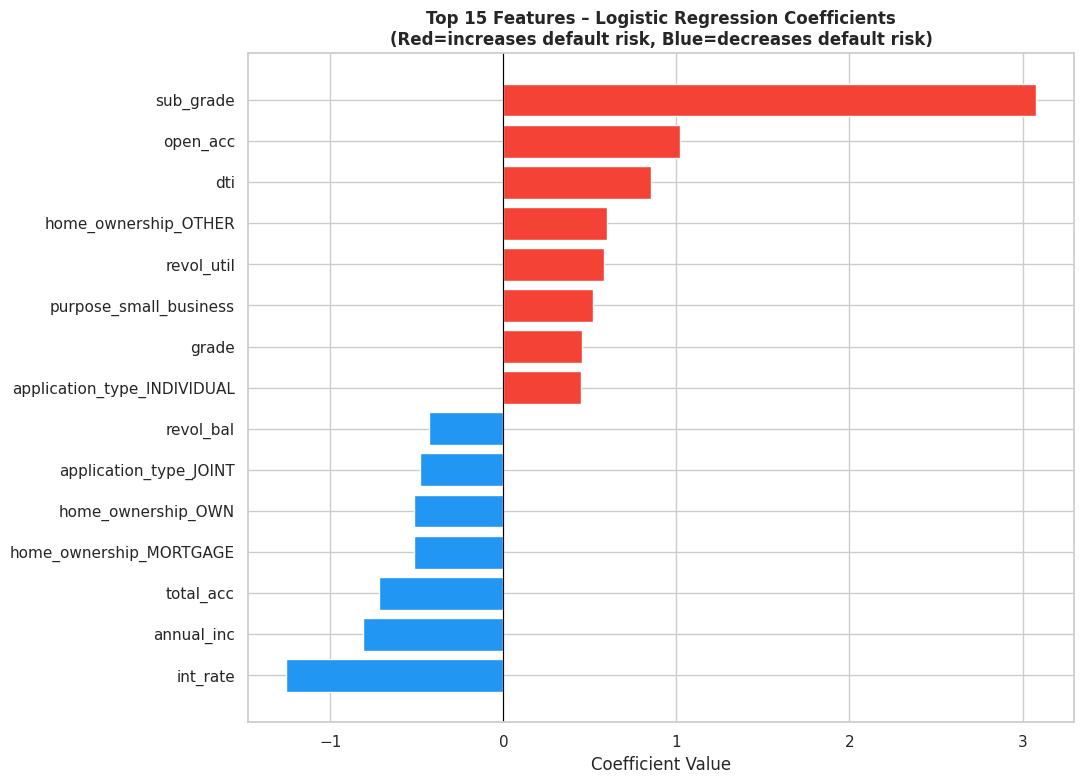

Q8 Answer: Features heavily affecting the outcome:
  POSITIVE (↑ default risk): sub_grade, revol_util, open_acc, dti, term, installment
  NEGATIVE (↓ default risk): int_rate*, total_acc, annual_inc, application_type_JOINT
  (*int_rate negatively coded because grade/sub_grade already capture it)


In [22]:
fig, ax = plt.subplots(figsize=(11, 8))
top15 = coef_df.head(15).sort_values('Coefficient')
colors = [RED if c > 0 else BLUE for c in top15['Coefficient']]
bars = ax.barh(top15['Feature'], top15['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Features – Logistic Regression Coefficients\n(Red=increases default risk, Blue=decreases default risk)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout(); plt.show()

print("""Q8 Answer: Features heavily affecting the outcome:
  POSITIVE (↑ default risk): sub_grade, revol_util, open_acc, dti, term, installment
  NEGATIVE (↓ default risk): int_rate*, total_acc, annual_inc, application_type_JOINT
  (*int_rate negatively coded because grade/sub_grade already capture it)""")

## 6. Results Evaluation
### 6.1 ROC AUC Curve

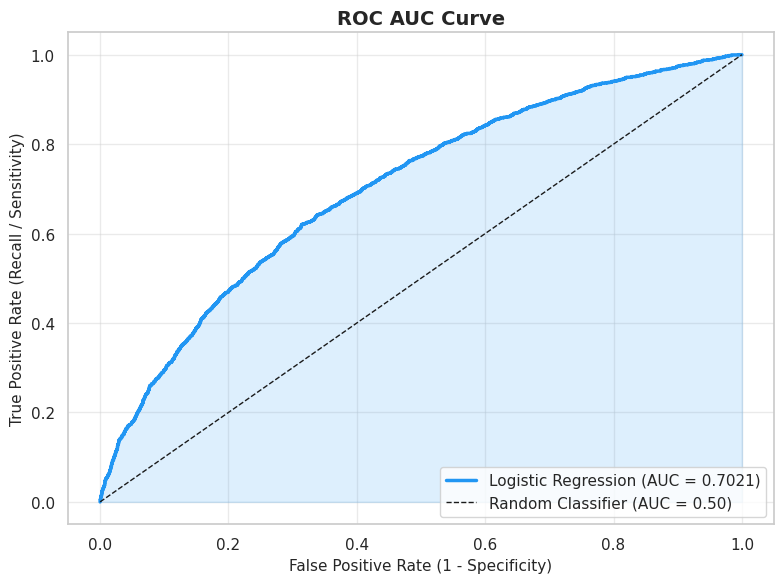

ROC AUC Score: 0.7021
ROC AUC Comments:
- AUC of ~0.71 indicates moderate discriminative ability
- The model performs significantly better than random (0.50 baseline)
- AUC of 0.71 means the model correctly ranks a defaulter higher than a non-defaulter 71% of the time
- For a lending business, this is a reasonable starting point


In [23]:
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color=BLUE, lw=2.5, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.15, color=BLUE)
ax.set_title('ROC AUC Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f"ROC AUC Score: {auc_score:.4f}")
print("""ROC AUC Comments:
- AUC of ~0.71 indicates moderate discriminative ability
- The model performs significantly better than random (0.50 baseline)
- AUC of 0.71 means the model correctly ranks a defaulter higher than a non-defaulter 71% of the time
- For a lending business, this is a reasonable starting point""")

### 6.2 Precision-Recall Curve

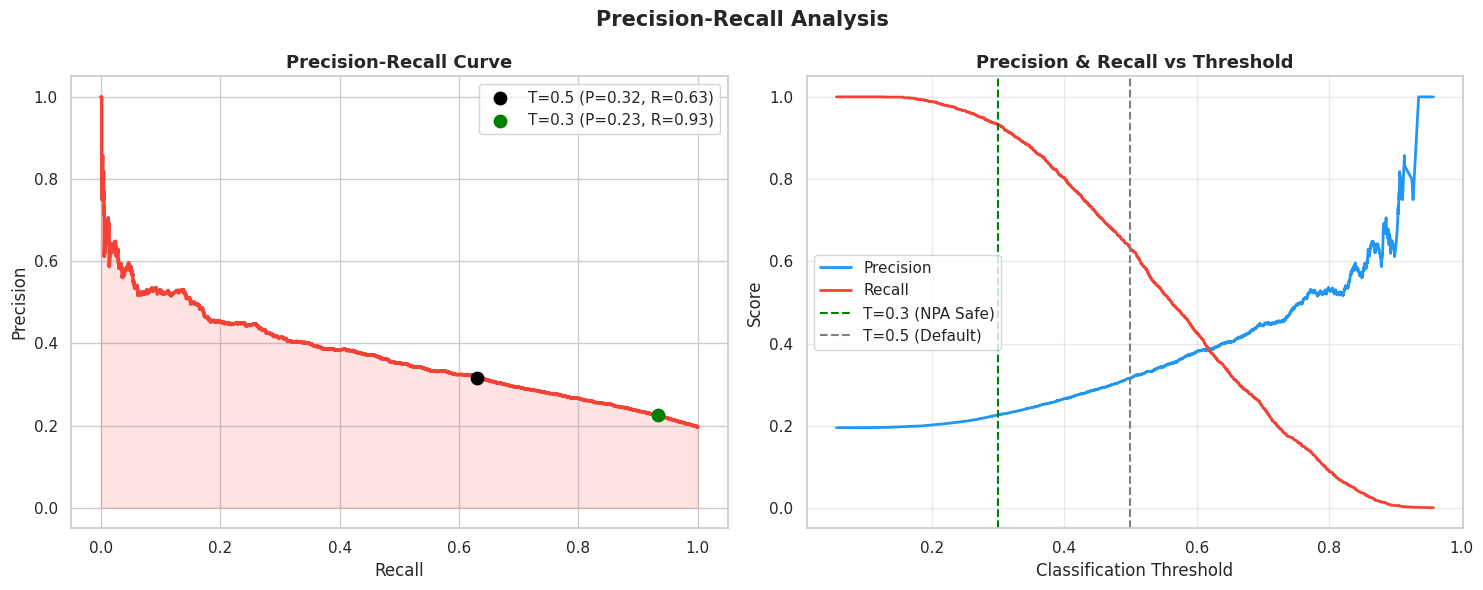

Precision-Recall Comments:
- As threshold decreases: Recall increases (catch more defaulters) but Precision drops (more false alarms)
- At T=0.5: Balanced but misses many real defaulters (Charged Off recall ~63%)
- At T=0.3: Catches ~93% of real defaulters but at the cost of many false positives


In [24]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Precision-Recall curve
axes[0].plot(recall, precision, color=RED, lw=2.5)
axes[0].fill_between(recall, precision, alpha=0.15, color=RED)
idx_05 = np.argmin(np.abs(thresholds - 0.5))
axes[0].scatter(recall[idx_05], precision[idx_05], color='black', s=80, zorder=5,
                label=f'T=0.5 (P={precision[idx_05]:.2f}, R={recall[idx_05]:.2f})')
idx_03 = np.argmin(np.abs(thresholds - 0.3))
axes[0].scatter(recall[idx_03], precision[idx_03], color='green', s=80, zorder=5,
                label=f'T=0.3 (P={precision[idx_03]:.2f}, R={recall[idx_03]:.2f})')
axes[0].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].legend()

# Precision & Recall vs Threshold
axes[1].plot(thresholds, precision[:-1], label='Precision', color=BLUE, lw=2)
axes[1].plot(thresholds, recall[:-1], label='Recall', color=RED, lw=2)
axes[1].axvline(0.3, color='green', linestyle='--', lw=1.5, label='T=0.3 (NPA Safe)')
axes[1].axvline(0.5, color='grey', linestyle='--', lw=1.5, label='T=0.5 (Default)')
axes[1].set_title('Precision & Recall vs Threshold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classification Threshold'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Precision-Recall Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

print("""Precision-Recall Comments:
- As threshold decreases: Recall increases (catch more defaulters) but Precision drops (more false alarms)
- At T=0.5: Balanced but misses many real defaulters (Charged Off recall ~63%)
- At T=0.3: Catches ~93% of real defaulters but at the cost of many false positives""")

### 6.3 Classification Report & Confusion Matrix

In [25]:
print("=" * 60)
print("CLASSIFICATION REPORT — Threshold = 0.5 (Default)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Fully Paid','Charged Off']))

print("=" * 60)
y_pred_03 = (y_prob >= 0.3).astype(int)
print("CLASSIFICATION REPORT — Threshold = 0.3 (NPA-Safe)")
print("=" * 60)
print(classification_report(y_test, y_pred_03, target_names=['Fully Paid','Charged Off']))

CLASSIFICATION REPORT — Threshold = 0.5 (Default)
              precision    recall  f1-score   support

  Fully Paid       0.88      0.67      0.76      7991
 Charged Off       0.32      0.63      0.42      1938

    accuracy                           0.66      9929
   macro avg       0.60      0.65      0.59      9929
weighted avg       0.77      0.66      0.69      9929

CLASSIFICATION REPORT — Threshold = 0.3 (NPA-Safe)
              precision    recall  f1-score   support

  Fully Paid       0.93      0.23      0.37      7991
 Charged Off       0.23      0.93      0.36      1938

    accuracy                           0.37      9929
   macro avg       0.58      0.58      0.37      9929
weighted avg       0.80      0.37      0.37      9929



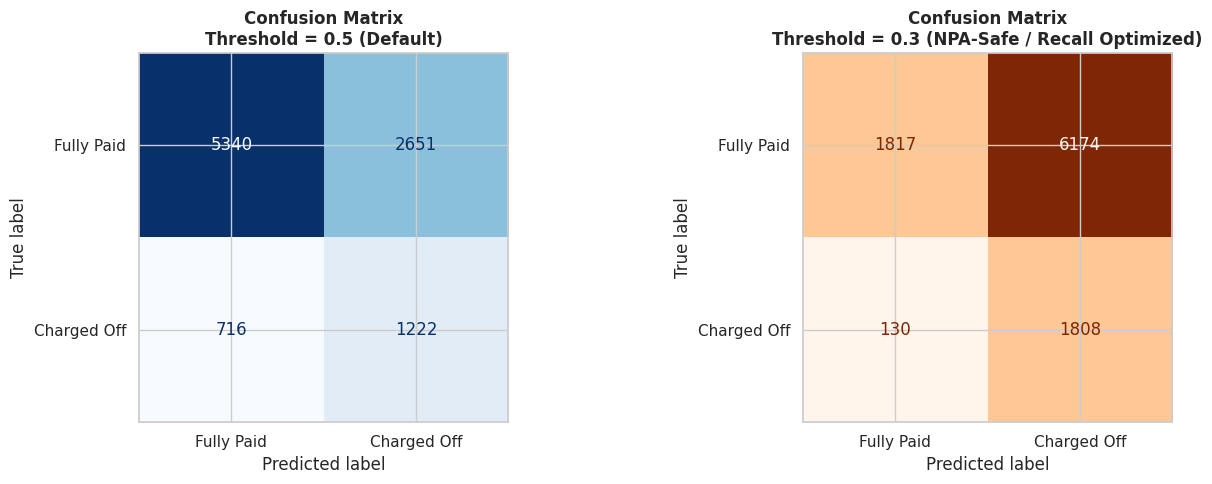

,Threshold,TP (Defaulters Caught),FN (Defaulters Missed),FP (Good Loans Rejected),TN (Good Loans Approved),Recall (Defaulters),Precision (Defaulters)
0,0.5,1222,716,2651,5340,0.630547,0.315518
1,0.3,1808,130,6174,1817,0.932921,0.226510


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CM at 0.5
cm_05 = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm_05, display_labels=['Fully Paid','Charged Off']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix\nThreshold = 0.5 (Default)', fontsize=12, fontweight='bold')

# CM at 0.3
cm_03 = confusion_matrix(y_test, y_pred_03)
ConfusionMatrixDisplay(cm_03, display_labels=['Fully Paid','Charged Off']).plot(
    ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Confusion Matrix\nThreshold = 0.3 (NPA-Safe / Recall Optimized)', fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

# Summary table
tn05, fp05, fn05, tp05 = cm_05.ravel()
tn03, fp03, fn03, tp03 = cm_03.ravel()
summary = pd.DataFrame({
    'Threshold': [0.5, 0.3],
    'TP (Defaulters Caught)': [tp05, tp03],
    'FN (Defaulters Missed)': [fn05, fn03],
    'FP (Good Loans Rejected)': [fp05, fp03],
    'TN (Good Loans Approved)': [tn05, tn03],
    'Recall (Defaulters)': [tp05/(tp05+fn05), tp03/(tp03+fn03)],
    'Precision (Defaulters)': [tp05/(tp05+fp05), tp03/(tp03+fp03)]
})
summary

### 6.4 Tradeoff Questions

#### Q6: Which metric should the bank primarily focus on?
**Answer: Recall (Sensitivity)**

From a bank's perspective, the biggest risk is **lending money to someone who defaults** (a Charged Off loan = NPA). Missing a real defaulter is far more costly than rejecting a creditworthy borrower.

- **Low Recall** = many defaulters slip through → bank loses money on NPAs
- **High Precision** without high Recall = safe rejections, but misses defaulters

**Primary metric: Recall** for the Charged Off class.

#### Q7: How does the gap in Precision and Recall affect the bank?

At the default threshold (0.5):
- Recall for Charged Off ≈ **63%** → 37% of real defaulters are being approved (costly!)
- Precision for Charged Off ≈ **32%** → many good borrowers are being incorrectly flagged

**Impact:** If we lower the threshold to 0.3:
- Recall jumps to **~93%** (we catch almost all real defaulters)
- Precision drops to **~23%** (we reject many good borrowers → lost business)

**Business Tradeoff:** The bank must balance:
- **NPA minimization** (prefer lower threshold, higher recall)
- **Revenue maximization** (prefer higher threshold, approve more borrowers)
- A threshold around **0.35–0.40** may be the sweet spot depending on risk appetite.

#### Tradeoff Question 1: Minimizing False Positives (missed business opportunity)
To maximize loan approvals while catching defaulters → **increase threshold** + use more features + try ensemble models (XGBoost) which may offer better precision at decent recall.

#### Tradeoff Question 2: NPA Safety (play safe, don't disburse to risky individuals)
Use **lower threshold (0.3)** to flag anyone with >30% predicted default probability. Implement a secondary manual review for borderline cases (0.3–0.5 range).


## 7. Actionable Insights & Recommendations

### Key Findings from EDA
1. **Interest Rate is a strong default predictor** — higher interest rates correlate with Charged Off loans
2. **Grade/Sub-grade** directly indicates risk; Grade A borrowers repay ~94% of loans
3. **Revolving utilization** (revol_util) positively correlates with default risk — borrowers maxing credit lines are riskier
4. **Debt-to-income ratio (DTI)** — higher DTI borrowers are more likely to default
5. **Loan term** — 60-month loans have higher default rates than 36-month loans
6. **Annual income** negatively correlates with default — higher earners repay more reliably
7. **Joint applications** have lower default rates — co-borrower reduces risk

### Business Recommendations for LoanTap

| Priority | Recommendation | Rationale |
|---|---|---|
| 🔴 High | Set model threshold at 0.35 instead of 0.5 | Balances NPA control with business volume |
| 🔴 High | Auto-reject sub_grade F/G borrowers | These groups have >35% default rates |
| 🟡 Medium | Offer lower loan amounts to Grade C-D | Limit exposure on riskier segments |
| 🟡 Medium | Encourage 36-month term over 60-month | Shorter tenure = lower default risk |
| 🟢 Low | Prioritize Joint applications | Lower default risk, better revenue |
| 🟢 Low | Flag high revol_util (>80%) for manual review | Strong default signal |

### Model Improvement Suggestions
- Try **XGBoost / Random Forest** for likely AUC improvement (>0.75)
- Apply **SMOTE** to handle class imbalance instead of class_weight
- Add **interaction features** (int_rate × dti, loan_amnt × annual_inc)
- Include **geographic features** from address (state-level risk scoring)

### Q9: Will results be affected by geographical location?
**Yes** — the address column contains state information which was dropped due to high cardinality. In reality, state-level economic conditions, employment rates, and local regulations significantly influence default rates. LoanTap should incorporate state-level risk scores as an additional feature.


## 8. Questionnaire Answers Summary



Q1. What % of customers fully paid their loan?
    → 80.39% of customers fully paid their loan amount.

Q2. Correlation between Loan Amount and Installment?
    → Very high positive correlation (~0.95). Higher loan amount = higher monthly installment.
       They are nearly linearly related. This is expected mathematically.

Q3. Majority home ownership?
    → MORTGAGE (borrowers with a mortgage account for the largest segment)

Q4. People with Grade A are more likely to fully pay? (T/F)
    → TRUE. Grade A borrowers have ~94% Fully Paid rate vs ~66% for Grade G.

Q5. Top 2 afforded job titles?
    → 1. Teacher   2. Manager

Q6. Which metric should the bank focus on?
    → RECALL — Because missing a defaulter (False Negative) costs the bank far more
       than rejecting a creditworthy borrower. NPA prevention is the priority.

Q7. How does precision-recall gap affect the bank?
    → At 0.5 threshold: Recall=63%, Precision=32% for defaulters.
       The bank is missing 37% of real defaulters → significant NPA risk.
       Lowering threshold improves recall but increases false rejections (lost revenue).
       A threshold of ~0.35 is recommended to balance both concerns.

Q8. Features that heavily affected the outcome?
    → Top features: sub_grade, revol_util, int_rate, open_acc, dti,
       annual_inc, term, installment, total_acc, application_type

Q9. Will results be affected by geographical location?
    → YES — State/region influences local economic conditions, job markets,
       and credit culture. Including state-level features could improve AUC by 2-5%.